# 5장 회귀

# 5.1 회귀 소개
정의1. 평균으로 회귀하려는 경향을 가진다는 자연의 법칙
정의2. 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법

- 5.1.1 Y = WX 
> Y: 종속 변수 / W: 회귀 계수 / X: 독립 변수

- 5.1.2 회귀 유형 구분
> 단일, 다중 / 선형, 비선형

- 5.1.3 지도학습 유형
> 분류: 예측값이 카테고리와 같은 이산형 클래스
> 회귀: 연속형 숫자값

- 5.1.4 선형회귀의 종류
> 1. 일반 선형 회귀 : 예측값과 실게값의 RSS를 최소화할 수 있도록 회귀 계수를 최족화하며 규제를 적용하지 않은 모델
> 2. 릿지(Ridge): 선형 회귀에 L2 규제를 추가한 회귀 모델 (L2 규제: 상대적으로 큰 회귀 계수 값의 예측 영향도를 감소시키기 위해서 회귀 계수값을 더 작게 만드는 규제 모델)
> 3. 라쏘(Lasso): 선형 회귀에 L1 규제를 적용하는 방식 (L1: 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않게 하는 것)
> 4. 엘라스틱넷(ElasticNet): L2, L1 규제가 결합한 모델
> 5. 로지스텍 회귀(Logistic Regression): 분류에 사용되는 선형 모델, 이진 분류뿐만 아니라 희소 영역의 분류, 예를 들어 텍스트 분류와 같은 영역에서 뛰어난 예측 성능을 보임

# 5.2 단순 선형 회귀를 통한 회귀 이해

### 5.2.1 구성
- 독립변수: X 1개
- 종속변수: Y 1개 
- 회귀계수: w0, w1 
- Y = w0 + w1*X
- 오류값 : 잔차 

### 5.2.2 RSS방식 (비용 함수 = 손실 함수)
- 잔차를 제곱하여 더하기
- RSS를 최소로하는 w0, w1을 찾는 것이 머신러닝 기반 회귀의 핵심사항
- **cost = loss**

# 5.3 비용 최소화하기 - 경사 하강법(Gradient Descent) 소개

### 5.3.1 경사 하강법의 역할
'점진적'으로 반복적인 계산을 통해 W 파라미터 값을 업데이트하면서 오류 값이 최소가 되는 W 파라미터를 구하는 방식

- R(w)를 w0와 w1으로 각각 편미분

- step 1. w1, w0를 임의의 값으로 설정하고 첫 비용 함수의 값을 계산 : R(w) 잔차 제곱의 평균
- step 2. w1과 w0를 편미분한 것에 '보정계수'를 적용하여 업데이트한 후 다시 비용 함수의 값을 계산
1. R(w)를 w0와 w1으로 각각 편미분
2. w0' = w0-편미분값 / w1' = w1-편미분값
**단, 편미분값이 너무 클 수 있기에 보정계수(학습률)를 적용하여 빼주기**
- step 3. 비용 함수가 감소하는 방향성으로 주어진 횟수만큼 step 2를 반복하면서 w1과 w0를 계속 업데이트

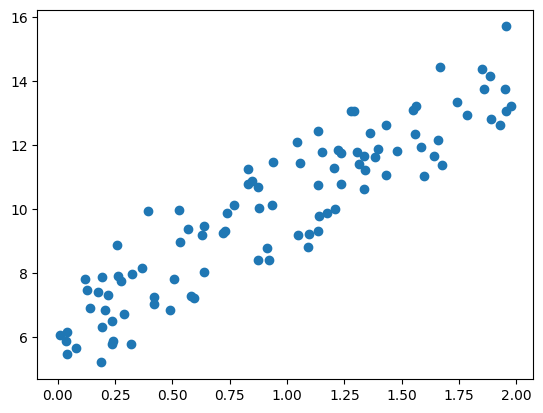

In [3]:
#5.3.1.1 데이터 산점도로 시각화
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
##y=4X+6을 근사(w1=4, w0=6), 임의의 값은 노이즈를 위해 만듦.
X = 2*np.random.rand(100,1)
y = 6+4* X+np.random.randn(100,1)

## X,y 데이터 세트 산점도로 시각화
plt.scatter(X,y)

In [22]:
#5.3.1.2 데이터 비용 함수로 계산 - get_cost()
def get_cost(y,y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

In [23]:
#5.3.1.3 경사 하강법 시행 - gradient_descent()
#(1) gradient_descent() 함수 : w1과 w0를 모두 0으로 초기화한 뒤 iters 개수만큼 반복하면서 w1과 w0를 업데이트
# 무작위로 생성한 X와 y를 입력받는데 X와 y 모두 넘파이 ndarray이다.

#(2) get_weight_update() 함수 : 입력 배열 X값에 대한 예측 배열 y_pred는 np.dot(X,w1.T)+w0로 구한다

##w1과 w0를 업데이트할 w1_update, w0_update를 반환
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
    N=len(y)
    ##먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    ##예측 배열 게산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X,w1.T) + w0
    diff = y-y_pred

    ##w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N,1))
    ##w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T,diff))

    return w1_update, w0_update

In [24]:
#5.3.1.4 gradient_descent_steps() : get_weight_updates를 반복적으로 수행하는 함수
##입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용
def gradient_descent_steps(X,y,iters=10000):
    #w0와 w1을 모두 0으로 초기화
    w0=np.zeros((1,1))
    w1=np.zeros((1,1))

    ##인자로 주어진 iters만큼 반복적으로 get_weight_updates() 호출해 w1,w0 업데이트 수행
    for ind in range(iters):
        w1_update, w0_update= get_weight_updates(w1,w0,X,y,learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [25]:
#5.3.1.5 w1,w0 출력 및 경사 하강법의 예측 오류 계산
def get_cost(y,y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

w1, w0 = gradient_descent_steps(X,y,iters=1000)
print("w1:{0:.3f} w1:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0]*X+w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.022 w1:6.162
Gradient Descent Total Cost:0.9935


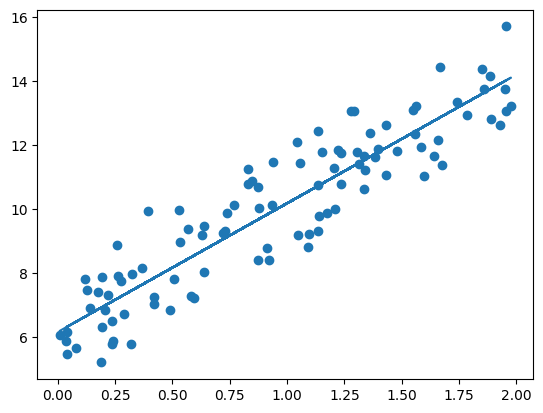

In [26]:
#5.3.1.6 회귀선 출력
plt.scatter(X,y)
plt.plot(X,y_pred)

#5.3.2 확률적 경사 하강법 - stochastic_gradient_descent_steps()
- 일반적으로 경사 하강법의 경우 수행을 하는 데 시간이 오래 걸림 >> 이를 보완하는 것이 '확률적' 경사 하강법
- 확률적 경사 하강법: 일부 데이터만 이용하여 w가 업데이트되는 값을 계산 >> 계산 속도 빠름

In [31]:
#5.3.2.1 확률적 경사 하강법 실행
def stochastic_gradient_descent_steps(X,y,batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost =100000
    iter_index =0

    for ind in range(iters):
        #####np.random.seed(iters)##### 뭐지 이게 있고 없고 간의 차이가 발생 ㅠ
        ##전체 X,y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, smaple_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        ##랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update=get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1=w1-w1_update
        w0=w0-w0_update

    return w1,w0

In [32]:
#5.3.2.2 계산 결과 및 예측 오류 비용 추산
# 결과가 5.3.1에서 진행한 것과 큰 차이X
w1,w0 =stochastic_gradient_descent_steps(X,y,iters=1000)
print("w1:", round(w1[0,0],3), "w0:", round(w0[0,0],3))
y_pred = w1[0,0]*X+w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1: 4.03 w0: 6.104
Stochastic Gradient Descent Total Cost:0.9973


# 5.4 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측 

In [4]:
#5.4.1.1 LinearRegression 클래스 - Ordinary Least Squares
# LinearRegression는 RSS(잔차의 제곱)가 되도록 OLS 추정 방식을 사용하여 W를 구하는 클래스
# fit()메서드로 X,y 배열을 입력받으면 회귀 계수(Coefficients)인 W를 coef_ 속성에 저장
from sklearn.linear_model import LinearRegression

# 최신 버전 기준 (normalize 매개변수 제외)
model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None)

In [ ]:
#5.4.1.2 다중공선성 문제
## 피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져서 오류에 민감 -> 다중공선성 문제 
## -> 상관관계가 높은 피처는 제거하거나 규제로 적용 or PCA를 통해 차원 축소를 수행 

In [ ]:
#5.4.2 회귀 평가 지표

### 평가 종류
1. MAE : 절댓값
2. MSE : 제곱
3. RMSE : 제곱의 제곱근
4. R^2 : 분산 기반으로 예측 성능 평가

In [ ]:
#5.4.3 LinearRegression을 이용해 보스턴 주택 가격 회귀 구현

In [7]:
#1단계 데이터 불러오기
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings # 1. s 추가
warnings.filterwarnings('ignore')

%matplotlib inline

# 2. 삭제된 load_boston() 대신 URL에서 데이터 직접 가져오기
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# 칼럼명 정의 (직접 입력)
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# DataFrame 변환
bostonDF = pd.DataFrame(data, columns=feature_names)

# PRICE 컬럼 추가
bostonDF['PRICE'] = target

print('Boston 데이터 세트 크기: ', bostonDF.shape)
bostonDF.head()

Boston 데이터 세트 크기:  (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


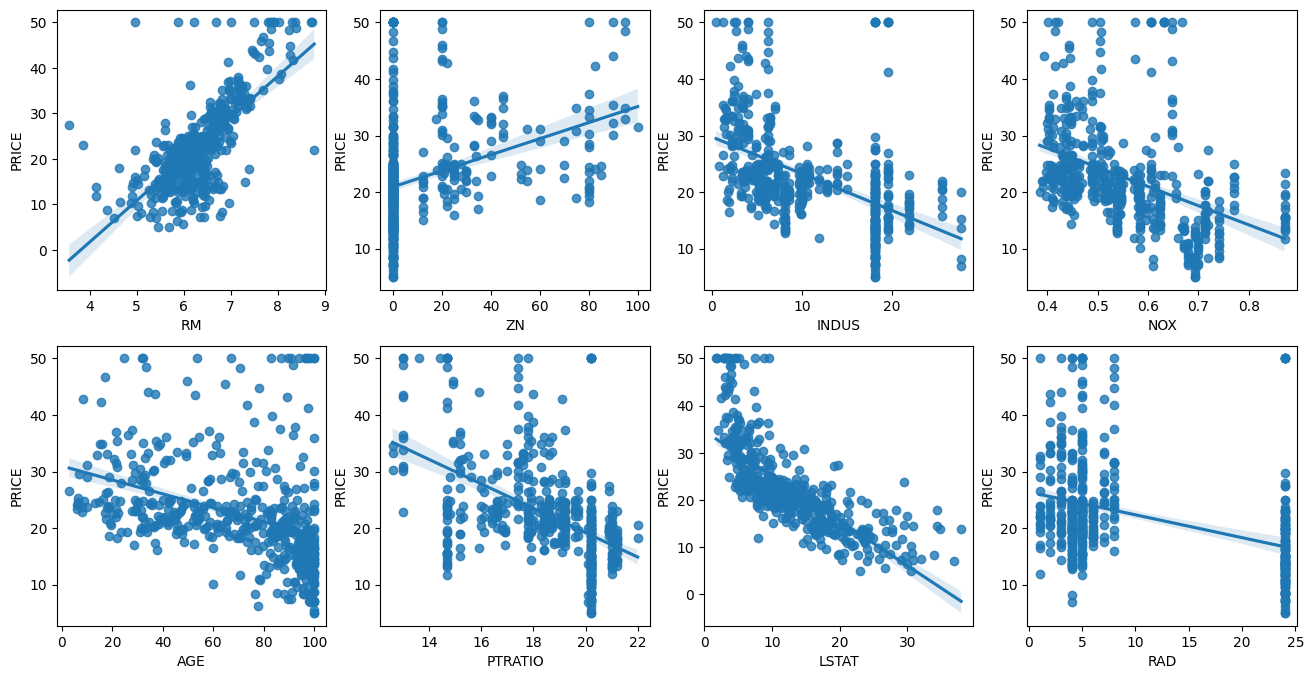

In [8]:
#2단계 시각화: regplot()으로 산점도와 함께 선형 회귀 직선 구현
# + matplotlob.subplots()로 ax마다 칼럼과 price의 관계 표현

##2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4*2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features= ['RM','ZN','INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    ##시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

In [11]:
#LinearRegression 클래스를 통해 회귀 모델 제작
#3단계. train_test_split()을 이용해 학습과 예측을 수행
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF[ 'PRICE' ]
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3,random_state=156)

# 선형 회귀 OLS로 학습/예측/평가 수행.
lr = LinearRegression()
lr. fit(X_train, y_train)

y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE: {0:.3f}, RMSE: {1:.3F}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE: 17.297, RMSE: 4.159
Variance score : 0.757


In [12]:
#3.2단계. 절편값-intercept와 회귀계수(coefficients) 확인
print('절편값:',lr.intercept_)
print('회귀 계수값:',np.round(lr.coef_,1))

절편값: 40.995595172164506
회귀 계수값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [14]:
#3.3단계. 회귀계수값 높은 값 순으로 출력
##회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_,1),index=X_data.columns)
coeff.sort_values(ascending=False)

RM          3.4
CHAS        3.0
RAD         0.4
ZN          0.1
INDUS       0.0
AGE         0.0
TAX        -0.0
B           0.0
CRIM       -0.1
LSTAT      -0.6
PTRATIO    -0.9
DIS        -1.7
NOX       -19.8
dtype: float64

In [16]:
#4단계. 교차 검증 시행 - 5개 fold 생성
from sklearn. model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

# CrosS_val_score()로 5 폴드 세트로 MSE 를 구한 뒤 이를 기반으로 다시 RMSE 구함.
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv= 5)
rmse_mse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# Cross_val Score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수
print(' 5 folds 의 개별 Negative MSE scores:' , np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores :', np.round(rmse_mse_scores,2))
print(' 5 folds 의 평균 RMSE : {0:3f}' .format (avg_rmse))

 5 folds 의 개별 Negative MSE scores: [-12.46 -26.05 -33.07 -80.76 -33.31]
 5 folds 의 개별 RMSE scores : [3.53 5.1  5.75 8.99 5.77]
 5 folds 의 평균 RMSE : 5.828659


# 5.5 다항 회귀와 과(대)적합/과소적합 이해

In [ ]:
#5.5.1 다항 회귀 이해

### 5.5.1.1 
1. 선형/비선형 구분
- 회귀에서 선형 회귀/비선형 회귀를 나누는 기준은 회귀 계수(w)가 선형/비선형인지에 따른 것이지 독립변수의 선형/비선형 여부와는 무관

2. 사이킷런에서 다항 회귀
- 사이킷런에서는 다항 회귀 클래스를 명시하지 않아 빗선형 함수를 선형 모델에 적용시키는 방법을 사용해 구현 가능

원래 데이터: x = 2 (이걸 주면 기계는 w*2 만 계산함)
가공된 데이터: x = [2, 4] (여기서 4는 2^2임)


In [17]:
#5.5.1.2 사이킷런에서의 다항 회귀 - polynomialFeatures 클래스 사용
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

##다항식으로 변환한 단항식 생성, [[0,1]],[[2,3]]의 2*2 행렬 생성
X=np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n',X)

##degree=2인 2차 다항식으로 변환하기 위해 PolynomialFeature를 이용해 변환
poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 계수 피처:\n', poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [18]:
#5.5.1.3(1) 3차 다항 회귀 함수를 임의로 설정하고 이의 회귀 계수를 예측
##먼저 3차 다항 회귀의 결정 함수식을 설정하고 이를 위한 polynomial_func()를 생성
def polynomial_func(X):
    y=1+2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature: \n', X)
y=polynomial_func(X)
print('삼차 다항식 결정값: \n',y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
삼차 다항식 결정값: 
 [  5 125]


In [19]:
#5.5.1.3(2) 앞서 일차 단항식 계수를 삼차 다항식 계수로 변환, 이를 선형 회귀에 적용하여 다항 회귀로 구현
##3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n', poly_ftr)

##Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynimial 회귀 계수\n', np.round(model.coef_,2))
print('Polynimial 회귀 shape:', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynimial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynimial 회귀 shape: (10,)


In [22]:
#5.5.1.3(3) Pipeline 객체를 이용해 한 번에 다항 회귀를 구현
from sklearn. preprocessing import PolynomialFeatures 
from sklearn. linear_model import LinearRegression 
from sklearn.pipeline import Pipeline
import numpy as no

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

# Pipeline 객체로 Streamline하게 Polynomial Feature 변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_,2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 5.5.2 다항 회귀를 이용한 과소적합 및 과적합 이해
다항 회귀의 차수를 높일수록 학습 데이터에만 너무 맞춘 학습이 이뤄져서 정작 테스트 데이터 환경에서는 오히려 예측 정확도가 떨어집니다

In [23]:
#5.5.2.1
##기존 데이터 세트는 피처X와 target y가 잡음이 포함된 다항식의 코사인 그래프 관계를 가지도록 만들어줍니다. 
##이에 기반해 회귀의 차수를 변화시키면서 그에 따른 회귀 예측 곡선과 예측 정확도를 비교하는 예제
###학습 데이터는 30개의 임의의 데이터인 X, 그리고 X의 코사인 값에서 약간의 잡음 변동 값을 더한 target인 y로 구성

import numpy as np 
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import cross_val_score 
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)
    
# x는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed (0)
n_samples = 30
X= np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE는 0.4077289625098685입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE는 0.04320874987232056입니다.

Degree 15 회귀 계수는 [-2.98291000e+03  1.03898880e+05 -1.87415324e+06  2.03715471e+07
 -1.44872830e+08  7.09313489e+08 -2.47065245e+09  6.24559902e+09
 -1.15676336e+10  1.56894743e+10 -1.54005873e+10  1.06457184e+10
 -4.91377255e+09  1.35919593e+09 -1.70380747e+08] 입니다.
Degree 15 MSE는 181238260.14863485입니다.


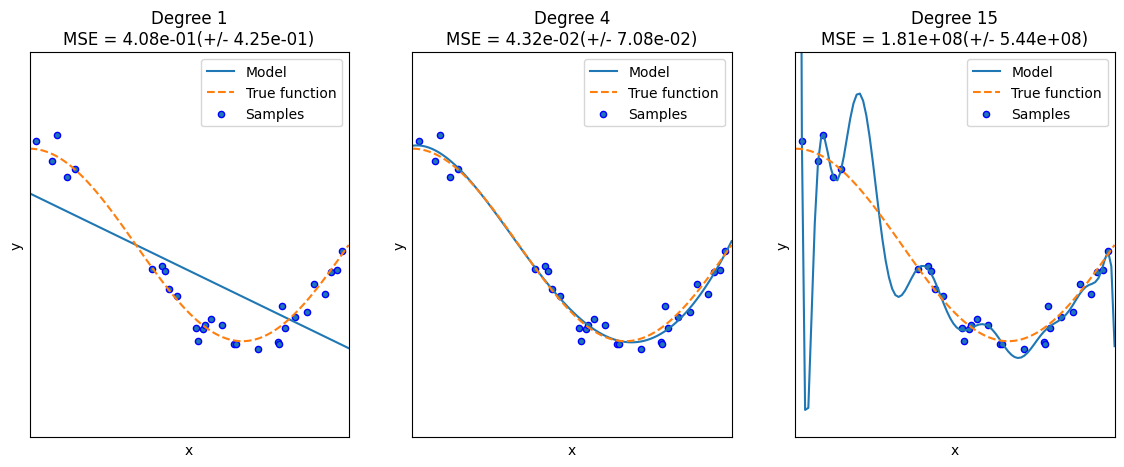

In [25]:
#5.5.2.2
#1. 다항식 차수를 1,4,15로 변경하여 예측 결과를 비교
#2. 이후 cross_val_score()로 MSE 값을 구해 차수별 예측 성능 평가
#3. 100개의 테스트용 데이터 세트를 이용해 차수별 회귀 예측 곡선

plt. figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    #개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE는 {1}입니다.'.format(degrees[i], -1*np.mean(scores)))
    
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim(0, 1); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))

plt.show()

#5.6 편향-분산 트레이드오프(Bias-Variance Trade off)
위의 케이스에서 확인할 수 있듯이..
- 1차: 고편향성
- 15차: 고분산성

> 편향을 낮추고 분산을 높이면서 전체 오류가 가장 낮아지는 '골디락스' 지점을 통과하면서 분산을 지속적으로 높이면 전체 오류 값이 오히려 증가하면서 예측 성능이 다시 저하
>> 편향과 분산이 서로 트레이드오프를 이루면서 오류 cost 값이 최대로 낮아지는 모델을 구축하는 것이 가장 효율적인 머신러닝 예측 모델!